# *Abies sibirica*: модель ареала в Енисейской Сибири 

**Цель работы**: создать модель, описывающую влияние характеристик внешней среды на распространение пихты сибирской на юге Енисейской Сибири. 

**Задачи**: 

1. На основе имеющихся данных о погоде, рельефе и пр. создать модель, наиболее адекватно описывающую современный ареал пихты сибирской. 
2. Ранжировать имеющиеся характеристики среды по их вкладу в распространение пихты. 

## 1. Подготовка к работе

### 1.1. Импорт библиотек и функций

<div alert class='alert alert-info'>

В ходе работы будут использованы следующие библиотеки и импорты из них: 

- `Annotator` – для помещения на графики данных о значимости различий при парном сравнении, 
- `DummyClassifier` – создание фиктивной модели для сравнения с ней результатов других моделей, 
- `RandomForestClassifier` – создание модели случайного леса, 
- `PartialDependenceDisplay` - для анализа частных зависимостей в модели, 
- `ProfileReports` из `ydata_profiling` – разведочный анализ данных, 
- `SelectFromModel` – отбор наиболее информативных признаков, 
- `StatTest` и `ks_2samp` – для сравнения по Колмогорову – Смирнову и передачи результатов в `Annotator`, 
- `XGBClassifier` и `lgb` – создание моделей градиентного бустинга, 
- `chi2_contingency` – для расчёта хи-квадрат, 
- `datetime` – получить системные дату и время для именования сохранённой модели, 
- `dendrogram` – графическое представление её результатов, 
- `io` – для чтения больших массивов данных (вспомогательная к `mmap`), 
- `json` – для загрузки конфигов, 
- `linkage` – кластеризация, 
- `math` – для округления вверх; 
- `mmap` – для работы с большими массивами исходных данных,
- `numpy` – вспомогательная библиотека, необходимая для работы с массивами, 
- `optuna` – поиск оптимальных гиперпараметров для строящихся моделей, 
- `os` – задать рабочую папку, 
- `pandas` – работа с таблицами, 
- `pickle` – сохранение и загрузка разработанных моделей, 
- `random` – для формирования случайных выборок, 
- `re` - переименование столбцов, 
- `roc_auc_score` и прочие `..._score` – расчёт величины метрик, 
- `seaborn` и `matplotlib` – создание графиков, 
- `scipy.stats` – расчёт значимости различий по Манну – Уитни и хи-квадрат, 
- `sys` - для прерывания выполнения кода при обнаружении ошибок в данных и загрузки скриптов, 
- `tqdm` - создание прогресс-баров, 
- `train_test_split` – разбиение данных на обучающую, валидационную и тестовую выборки, 
- `warnings` – предотвратить появление сообщений об ошибках для улучшения читаемости результатов, 
- `winsound` – для подачи сигнала в случае прерывания кода из-за ошибки в данных, 
- `xgboost` – для оценки значимости отдельных предикторов.

</div>

In [1]:
# # импорт библиотек
from datetime import datetime
import os 
import pickle 
import sys
import warnings 
import winsound

import json
import keyboard
from lightgbm import LGBMClassifier
import numpy as np
import optuna
import pandas as pd 
from scipy.stats import chi2_contingency
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier 
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, fbeta_score 
from xgboost import XGBClassifier 
from ydata_profiling import ProfileReport


C:\Users\user\AppData\Local\Temp\ipykernel_19756\1302157271.py:20: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


### 1.2. Объявление пользовательских функций

<div class='alert alert-info'>

Функция `calculate_weather_data` использьуется для подготовке данных к расчёту среднемесячных значений признаков погоды и передачи результатов далее. Аргументы: 

- `data_abies`: фрейм данных о точках с преобладанием пихты; 
- `data_not_abies`: фрейм данных о точках с преобладанием других древесных пород; 
- `geogr_feat`: список с текстовыми значениями названий (кодов) характеристик местности, включая географические координаты;
- `weather_feat`: список с текстовыми значениями названий (кодов) признаков погоды; 
- `month_num`: список с номерами месяцев в формате ММ (например, 03 или 11).

</div>

<div class='alert alert-info'>

Функция `format_fn` нужна для форматирования подписей при засечках на оси, чтобы они не накладывались друг на друга. Выполняется внутри `partial_deps_and_violins`. Аргументы: 

- `tick_val`: подпись при засечке; 
- `tick_pos`: аргумент, указывающий положение подписи. 

</div>

<div class='alert alert-info'>

Функция `load_raw_data` нужна для загрузки и погодных характеристик части исследуемых точек. Она выполняется внутри функции `load_weather_partially`, которая приводит результаты её работы к виду, пригодному для дальнейшего применения. Аргументы: 

- `file_name`: название файла с предикторами; 
- `seed`: зерно для генератора случайных чисел (для обеспечения воспроизводимости результатов); 
- `size`: объём загружаемых данных (строк). 

</div>

<div class='alert alert-info'>

Функция `load_weather_completely` нужна для загрузки и предварительной обработки погодных характеристик части исследуемых точек, чтобы после обработки функцией `weather_means` передать эти данные для создания карты для полного объёма данных. Аргументы: 

- `abies_file`: название файла с предикторами для участков с доминированием пихты; 
- `other_file`: название файла с предикторами для участков с доминированием других древесных пород; 
- `root_dir`: адрес корневой папки; 
- `chunk_volume`: количество строк, загружаемых в чанк; 
- `model`: проверяемая модель; 
- `mode`: опция, задающая, какой лесообразователь будет обработан: пихта (`abies`) или всё остальное (`other`); 
- `test`: булева опция, задающая количество загружаемых чанков (если `True`, обрабатываются только три из них, чтобы проверить работу функции за разумное время). 

</div>

<div class='alert alert-info'>

Функция `load_weather_partially` нужна для загрузки и предварительной обработки погодных характеристик части исследуемых точек, чтобы после обработки функцией `weather_means` передать эти данные для обучения. Аргументы: 

- `abies_file`: название файла с предикторами для участков с доминированием пихты; 
- `othersp_file`: название файла с предикторами для участков с доминированием других древесных пород; 
- `root_dir`: адрес корневой папки; 
- `data_volume`: доля загружаемых данных из каждого файла; 
- `n_chunks`: количество чанков для передачи в `random_df_chanks`; 
- `seed`: затравка для генерации случайных чисел, обеспечивающая воспроизводимость. 

</div>

<div class='alert alert-info'>

Функция `optimize_model` нужна для обучения моделей и оптимизации гиперпараметров с помощью *Optuna*. На выход подаётся наилучшее (для всех исследуемых алгоритмов обучения) значение метрики и наилучшая с точки зрения этой метрики модель. Кроме того, функция отбирает наиболее информативные с точки зрения прогнозирования характеристики территории. Аргументы: 

- `pred_train`, `pred_valid`: фреймы с предикторами, используемыми при обученнии и валидации соответственно; 
- `veg_train`, `veg_valid`: списки с метками классов, используемые при обучении и валидации соответственно; 
- `t_metric_dummy`: значение целевой метрики для фиктивного классификатора; 
- `best_metrics`: фрейм для записи значений метрик лучшей модели (целевая, *accuracy*, *precision*, *recall*); 
- `best_retained_columns`: имена столбцов признаков, нужных для работы лучшей модели; 
- `parameters`: функция для подачи параметров в обучалку *Optuna* (здесь `get_params`, определяемая для каждого алгоритма отдельно); 
- `model`: исследуемый класс модели машинного обучения; 
- `target_metric`: целевая метрика (*ROC-AUC* `roc_auc` или *Fbeta* `fbeta`); 
- `index`: индекс строки во фрейме, где сохраняются значения метрик; 
- `algorythm`: название исследуемого алгоритма машинного обучения; 
- `study_name`: имя *Optuna study*; 
- `t_metric_best`: значение целевой метрики, лучшее на момент начала обучения данного алгоритма; 
- `model_best`: лучшая на данный момент модель, 
- `best_algorythm`: лучший на данный момент алгоритм. 

</div>

<div class='alert alert-info'>

Функция `partial_deps_and_violins` нужна для создания графиков частных зависимостей и скрипичных графиков, что позволяет графически оценить зависимость результатов работы модели от значений предикторов. Аргументы: 

- `model`: проверяемая модель; 
- `pred_test`: тестовый набор предикторов; 
- `veg_test`: тестовый набор значений зависимой переменной; 
- `path_to_folder`: путь к целевой папке. 

</div>

<div class='alert alert-info'>

Функция `plot_map_and_save_data` нужна для создания карт, отображающих результаты моделирования, и сохранения исходных данных для этих карт. Последнее нужно для оценки совпадения результатов работы разных моделей. Аргументы: 

- `for_map`: фрейм с предикторами и зависимой переменной (т.е., данными о преобладающей породе); 
- `predictors`: фрейм с предикторами без данных о зависимой переменной; 
- `used_predictors`: фрейм с именами предикторов, используемых в работе модели; 
- `model`: проверяемая модель; 
- `pred_test`: тестовый набор предикторов, нужный только для упорядочивания столбцов в `predictors` перед передачей в модель; 
- `path_to_folder`: путь к целевой папке. 

</div>

<div class='alert alert-info'>

Функция `plot_map` нужна для создания субграфиков-карт, где точки с разными значениями некоторого качественного свойства обозначаются разными цветами. Выполняется внутри `plot_map_and_save_data`. Аргументы: 

- `ax`: ось `matplotlib`, в которую передаётся график; 
- `df`: фрейм, содержащий данные для графика; 
- `feature`: признак (название столбца) для которого строится график; 
- `title`: заголовок графика; 
- `color_list`: список цветов для каждого значения свойства (должен совпадать по длине с уникальными значениями `feature`); 
- `legend_names`: список названий значений, т.е., элементов легенды; по умолчанию отсутствует, тогда названия берутся из обрабатываемого столбца `feature`. 

</div>

<div class='alert alert-info'>

Функция `prepare_datasets` готовит обучающую, валидационную и тестовую выборки, а также фрейм `for_map`, несущий дополнительную информацию для построения карт. Аргументы: 

- `data_abies`: имя фрейма с исходниками для пихты; 
- `data_not_abies`: то же, для других лесообразователей; 
- `path_to_folder`: путь к папке с моделью;  
- `fname`: имя лог-файла. 

</div>

<div class='alert alert-info'>

Функция `read_log` читает для данной модели информацию из лог-файла или готовит данные для построения карты. Нужна для сравнения моделей, если режим обучения выключен (`"TRAIN_MODEL": false` в конфиге). Аргументы: 

- `root`: путь к корневому каталогу; 
- `model`: имя модели (нужно для создания пути к логу); 
- `for_map`: имя фрейма (в ноутбуке `for_map`) с информацией, нужной для создания карт;  
- `pred_test`: имя фрейма с предикторами, который затем понадобится при создании карт; 
- `mode`: режим работы функции. 

Если `mode='map`, то на вход подаются данные из лог-файла об использованных моделью предикторах, а на выходе будут фреймы `used_predictors`, `for_map` и `pred_test`, которые нужны для создания карт. Если `mode='model'`, на вход пойдут данные из лог-файла о метриках моделей, обученных с конкретной целевой метрикой, и результаты работы лучшей из них. На выходе будут данные о целевой метрике (`target_metric`, текстовый), метриках для разных алгоритмов (`metrics`, фрейм) и результатах работы лучшей модели (`prognosis_data`, список). 

</div>

<div class='alert alert-info'>

Функция `remove_multicollinear` удаляет предикторы, создающие мультиколлинеарность. Аргументы: 

- `data`: фрейм с исходными данными, используемый для анализа мультиколлинеарности; 
- `train`, `valid`, `test`: наборы данных для обучения, валидации и тестирования, из которых функция удаляет лишние предикторы; 
- `dt`: строковый объект, содержащий информацию о дате и времени начала обучения модели (нужно для создания путей);  
- `fname`: имя лог-файла; 
- `allowed_vif`: максимально допустимое для оставшихся предикторов значение VIF. 

На выход подаёт фреймы `pred_train`, `pred_valid`, `pred_test`, т.е., наборы предикторов с удалёнными мультиколлинеарными признаками, фрейм `for_ydp`, далее используемый для разведочного анализа данных, и фрейм `vif_data`, показывающий значения VIF для каждого из оставшихся предикторов. 

</div>

<div class='alert alert-info'>

Функция `save_best_model` сохраняет лучшую модель, обученную для данной целевой метрики. Аргументы: 

- `model_best`: сохраняемая модель; 
- `dt`: строковый объект, содержащий информацию о дате и времени начала обучения модели (нужно для создания имени модели); 
- `path_to_folder`: путь к папке с моделью; 
- `fname`: имя лог-файла; 
- `best_algorythm`, `t_metric_best`, `t_metric_test`, `best_metrics`, `used_predictors`: соответственно, алгоритм лучшей модели; значения целевой метрики на валидации и тесте; значения метрик (целевая, accuracy, precision, recall) для всех моделей, обученных для данной целевой метрики; набор предикторов. 

</div>

<div class='alert alert-info'>

Функция `weather_means` использьуется для расчёта средних значений погодных характеристик внутри `calculate_weather_data`. На вход принимает три аргумента: 

- `data`: фрейм данных; 
- `feature`: текстовый шаблон, обозначающий интересующую погодную характеристику; 
- `month`: номер месяца в формате ММ (например, 03 или 11).

</div>

### 1.3. Установка значений некоторых опций и констант

In [2]:
# Нужно, чтобы при отладке не перезапускать ноутбук каждый раз 
# после внесения правок в скрипт. 
%load_ext autoreload
%autoreload 2

In [3]:
# для улучшения читаемости проекта запретим показывать предупреждения
warnings.filterwarnings("ignore")

In [4]:
# загрузить конфиг
with open('C:/Users/user/Yandex.Disk/Важные документы/Исходные данные для статей/Моделирование вспышек/Моделирование ареала пихты/Abies_01/config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

# определить, будет ли вестись расчёт характеристик погоды (если False, то загружать ранее рассчитанные)
BETA = config['BETA']
# будем ли мы рассчитывать характеристики погоды
CALCULATE_FEATURES = config['CALCULATE_FEATURES']
# сравниваем ли мы результаты работы разных моделей
COMPARE_MODELS_RESULTS = config['COMPARE_MODELS_RESULTS']
# параметры работы ydata-profiling
COMPARISON_REPORT_PARAMS = config['YDATA_REPORT_PARAMS']
# количество объектов в выборках для пихты и прочих пород
DATA_VOLUME = config['DATA_VOLUME']
# будем ли выполнять разведочный анализ
EDA = config['EDA']
# имя модели, используемой в работе
MODEL_NAME = config['MODEL_NAME']
# путь к выбранной модели
MODEL_PATH = config['MODEL_PATH']
# папка для сохранения результатов сравнения моделей
MODELS_COMPARISON = config['MODELS_COMPARISON']
# количество проходов Optuna
N_TRIALS = config['N_TRIALS']
# загрузить названия файлов с данными по пихте и прочим лесообразователям
NAME_ABIES_FILE = config['NAME_ABIES_FILE']
NAME_OTHERSP_FILE = config['NAME_OTHERSP_FILE']
# адрес корневой папки
ROOT_DIR = config['ROOT_DIR']
# SEED
SEED = config['SEED']
# целевую метрику
TARGET_METRIC = config['TARGET_METRIC']
# определить, будут ли обучаться модели (если False, то загружать ранее обученные)
TRAIN_MODEL = config['TRAIN_MODEL']

In [5]:
# нужно для уверенной загрузки скриптов из папки 'scripts'
scripts_path = os.path.join(ROOT_DIR, "scripts")

if scripts_path not in sys.path:
    sys.path.append(scripts_path)


In [6]:
# выведем на экран значения опций, задающих работу ноутбука
print('За этот проход мы ')
if CALCULATE_FEATURES: 
    print('    - рассчитываем значения характеристик погоды; ')
if EDA: 
    print('    - выполняем разведочный анализ; ')
if TRAIN_MODEL: 
    print('    - обучаем модель; ')
if COMPARE_MODELS_RESULTS: 
    print('    - сравниваем ранее обученные модели.')


За этот проход мы 
    - обучаем модель; 
    - сравниваем ранее обученные модели.


In [7]:
# получим от пользователя согласие с опциями из ячейки выше
winsound.Beep(1000, 1000)
print('Если вы согласны с опциями в ячейке выше, нажмите пробел для продолжения выполнения кода. ')
keyboard.wait("space")

Если вы согласны с опциями в ячейке выше, нажмите пробел для продолжения выполнения кода. 


### 1.4. Создание папок и лог-файла

In [8]:
# папки создаём только если их ещё нет и если обучаем модель
# Создадим строку с датой, далее будем её использовать для именования файлов и папок. 
# Это нужно вне зависимости от того, будет ли обучаться модель. 
dt2 = datetime.now().strftime('%Y_%m_%d_%H_%M')

# если обучаем модель
if TRAIN_MODEL:
    try:
        # создадим папку для модели и лога
        if TARGET_METRIC == 'roc_auc':
            os.mkdir(ROOT_DIR + '/models/abies_area_model_' + TARGET_METRIC)
            path_to_trained_model = os.path.join(ROOT_DIR + '/models/abies_area_model_' + TARGET_METRIC)
        elif TARGET_METRIC == 'fbeta': 
            os.mkdir(ROOT_DIR + '/models/abies_area_model_' + TARGET_METRIC + '_' + str(BETA))
            path_to_trained_model = os.path.join(ROOT_DIR + '/models/abies_area_model_' + TARGET_METRIC + '_' + str(BETA))
        else: 
            raise(f"Неподдерживаемая метрика: '{TARGET_METRIC}'. Ожидалось 'roc_auc' или 'fbeta'.")
    except FileExistsError: 
        print('Папка для работы с моделью уже существует')
        raise
else: 
    path_to_trained_model = os.path.join(ROOT_DIR + MODEL_PATH)




In [9]:
# если обучаем модель
if TRAIN_MODEL: 
    # создадим строку с датой для записи в лог
    dt1 = datetime.now().strftime("%d.%m.%Y %H:%M")
    # создадим имя лог-файла
    fname = 'log_abies_area_model_' + dt2 + '.txt'
    # зададим рабочую папку
    os.chdir(path_to_trained_model)
    try: 
        # попытаемся создать лог-файл и записать в него дату работы
        with open(fname, 'a', encoding='cp1251') as file:     
            file.write(f'Обучение модели начато {dt1}. \n')
    except: 
        print('Проблемы с созданием лог-файла')
else: 
    fname = None


In [10]:
# если обучаем модель
if TRAIN_MODEL:
    del dt1

## 2. Работа с данными

### 2.1. Импорт и подготовка данных

<div class='alert alert-info'>

Данные о погоде скачаны Сашей Шушпановым из [ERA5-Land для единственного уровня](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=overview) (всё, кроме относительной влажности) и [для давления 1000 Па](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels-monthly-means?tab=overview) для периода с января 1940 по январь 2026 года. 

Древостои по преобладающей породе разделяли следующим образом: в одну группу относили те, которые всём временном протяжении (с 2006 по 2018 гг.) [по данным Барталёва](http://d33.infospace.ru/d33_conf/sb2015t5/203–221.pdf) были заняты пихтовыми древостоями, в другую те, где преобладание пихты на этом же временном промежутке не распознавалось ни в один год. 

Им же добавлены данные о рельефе из [EarthExplorer](https://www.usgs.gov/centers/eros/science/usgs-eros-archive-digital-elevation-shuttle-radar-topography-mission-srtm-1?qt-science_center_objects=0#qt-science_center_objects). 

</div>

<div class='alert alert-info'>

*Спецификация данных*: 

- `pointid`: код полигона; 
- `grid_code`: ?; 
- `swvl1` = `soil_water`: содержание воды в верхнем слое почвы, м<sup>3</sup> м<sup>–3</sup>; 
- `total_precipitation` = `pre`: осадки, м ~~или кг м<sup>–2</sup> с<sup>–1</sup>(?)~~; 
- `snow_depth`: глубина снежного покрова, м водного эквивалента; 
- `evaporation` = `evap`: эвапорация, м водного эквивалента; 
- `relative_humidity` = `rel_hum`: относительная влажность воздуха, % в документации к набору данных, реально доли единицы; 
- `2m_temperature` = `2m_temp`: температура в приземном слое воздуха, °К;
- `dem`: высота над уровнем моря (?), м; 
- `aspect`: ориентация склона, °; 
- `slope`: крутизна склона, °;
- `curvature`: изгиб склона; 
- `point_x`, `point_y`: координаты полигона. 

Для данных о погоде временнОй промежуток кодируется в виде 'b + число + нижнее подчёркивание' (например, b10_), где число 1 соответствует январю 1940 года, а последний промежуток, приходящийся на январь 2026 года, кодирован числом 1032. 

</div>

In [11]:
# если рассчитываем значения характеристик погоды (вместо использования рассчитанных ранее)
if CALCULATE_FEATURES: 
    from load_weather_partially import load_weather_partially
    # загрузка исходных данных для расчёта характеристик погоды
    data_abies, data_not_abies = load_weather_partially()



### 2.2. Расчёты средних значений для погоды

In [12]:
# если рассчитываем значения характеристик погоды (вместо использования рассчитанных ранее)
if CALCULATE_FEATURES:
    from calculate_weather_data import calculate_weather_data
    # расчёт среднемноголетних значений признаков погоды (предикторов)
    data_abies_g, data_not_abies_g = calculate_weather_data(data_abies=data_abies, data_not_abies=data_not_abies)
    # сохранение среднемноголетних значений
    try:
        data_abies_g.to_csv(os.path.join(ROOT_DIR, 'data/abies.csv'))
        data_not_abies_g.to_csv(os.path.join(ROOT_DIR, 'data/not_abies.csv'))
        print('Предикторы успешно сохранены. ')
    except: 
        print('Ошибка сохранения предикторов.')
# если загружаем рассчитанные ранее значения предикторов (CALCULATE_FEATURES == False)
else: 
    # загрузка ранее рассчитанных среднемноголетних значений признаков погоды (предикторов)
    data_abies_g = pd.read_csv(os.path.join(ROOT_DIR, 'data/abies.csv'), index_col=0)
    data_not_abies_g = pd.read_csv(os.path.join(ROOT_DIR, 'data/not_abies.csv'), index_col=0)

### 2.3. Графический анализ данных

<div class='alert alert-warning'>

При обработке большого объёма данных (10k строк) в некоторых переменных появились пропущенные значения, вернее, только одно. Такие пропуски и создают проблему при загрузке, вынуждая дополнительно конвертировать данные в количественный формат через `pd.to_numeric`. 

</div>

In [13]:
# если выполняем разведочный анализ
if EDA:
    # сравнение данных для пихты и прочих сообществ, их анализ
    report_abies = ProfileReport(
        data_abies_g, 
        title="Abies", 
        **COMPARISON_REPORT_PARAMS
        )
    report_not_abies = ProfileReport(
        data_not_abies_g, 
        title="Other species", 
        **COMPARISON_REPORT_PARAMS
        )

    # сравниваем их
    comparison_report = report_abies.compare(report_not_abies)
    
    # если обучаем модель
    if TRAIN_MODEL:
        # сохраняем в HTML
        os.chdir(ROOT_DIR + '/eda')
        comparison_report.to_file("comparison.html")
    # если не обучаем модель
    else: 
        # выводим результаты сравнения на дисплей
        comparison_report.to_notebook_iframe()


In [14]:
# если выполняем разведочный анализ
if EDA:
    del comparison_report, report_abies, report_not_abies

<div class='alert alert-info'>

Данные о снежном покрове с мая по сентябрь очевидно бессмысслены (см. их разброс в отчётах `ydata-profiling`), поэтому ниже мы их удалим. 

</div>

In [15]:
# удалим очевидно бессмыссленные данные о снежном покрове с мая по сентябрь
data_abies_g = data_abies_g.drop(
    ['snow_depth_05', 'snow_depth_06', 'snow_depth_07', 'snow_depth_08', 'snow_depth_09'], axis=1
    )
data_not_abies_g = data_not_abies_g.drop(
    ['snow_depth_05', 'snow_depth_06', 'snow_depth_07', 'snow_depth_08', 'snow_depth_09'], axis=1
    )

### 2.4. Подготовка выборок

<div class='alert alert-info'>

В начале работы подготовим список `vegetation`, где единица означает присутствие пихтового древостоя, ноль – его отсутствие. Далее объединим подготовленные ранее фреймы с предикторами (характеристиками местности и погоды). Эти объекты уже будем делить на обучающую, тестовую и валидационную выборки в соотношении *0.5/0.25/0.25*.

В этом же разделе подготовим фрейм `for_map`, который ниже дополним результатами работы модели и используем для создания карт.

</div>

In [16]:
from prepare_datasets import prepare_datasets
# готовим обучающий, валидационный и тестовый наборы данных, а также набор 'for_map' для создания карт
for_map, pred_train, pred_valid, pred_test, veg_train, veg_valid, veg_test = prepare_datasets(
    data_abies_g, 
    data_not_abies_g, 
    path_to_folder=path_to_trained_model, 
    fname=fname
    )

Размер обучающей выборки 15360 объектов, размер промежуточной – 15360 объектов.
Размер валидационной выборки 7680 объектов, размер тестовой – 7680 объектов.
Доля участков с преобладанием пихты в обучающем наборе: 0.07565.
Доля участков с преобладанием пихты в валидационном наборе: 0.07122.
Доля участков с преобладанием пихты в тестовом наборе: 0.07357.


### 2.5. Группировка предикторов и удаление мультиколлинеарных

In [17]:
# загружаем данные из лога, если работаем с ранее обученной моделью
if not TRAIN_MODEL and not COMPARE_MODELS_RESULTS: 
    from read_log import read_log

    used_predictors, for_map, pred_test = read_log(
        root=ROOT_DIR, model_path=path_to_trained_model, for_map=for_map, pred_test=pred_test, mode='map'
        )


Группировка предикторов: 


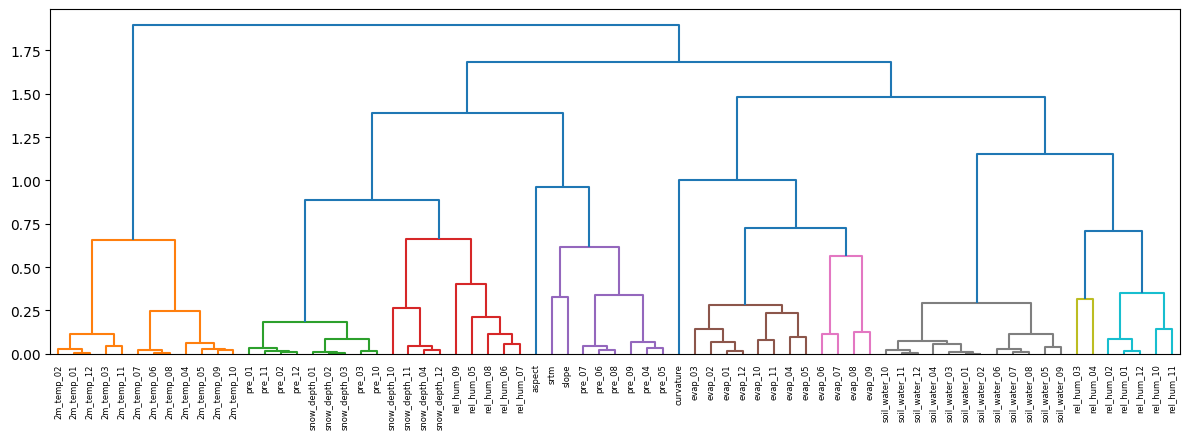

Удаляем: evap_03 (VIF=5.43)16))84))))

,Variable,VIF
6,snow_depth_10,4.701257
7,evap_04,4.377250
10,rel_hum_04,4.210134
9,evap_11,4.062858
5,pre_07,3.604427
12,rel_hum_12,3.043346
4,pre_01,2.476978
11,rel_hum_09,2.372740
1,slope,1.828644
8,evap_07,1.750828


In [18]:
%matplotlib inline

# создадим фрейм с предикторами
predictors = pd.concat([data_abies_g, data_not_abies_g], axis=0)

# если обучаем модель
if TRAIN_MODEL: 
    from remove_multicollinear import remove_multicollinear

    # избавимся от мультиколлинеарности
    pred_train, pred_valid, pred_test, for_ydp, vif_data = remove_multicollinear(
        data=predictors, 
        train=pred_train, 
        valid=pred_valid, 
        test=pred_test, 
        path_to_folder=path_to_trained_model, 
        fname=fname
        )

    # отобразим значения VIF для оставшихся предикторов
    display(vif_data)
# если работаем с загруженной ранее обученной моделью
else:
    vegetation = [
        *np.ones(int(predictors.shape[0] / 2)).tolist(), 
        *np.zeros(int(predictors.shape[0] / 2)).tolist()
        ]
    # создадим фрейм для разведочного анализа, скопировав в него данные о предикторах
    for_ydp = predictors.copy()
    # оставим в нём только предикторы с низким VIF
    for_ydp = for_ydp[list(used_predictors['feature'])]
    # добавим данные о растительности (пихтовые древостои либо древостои других пород)
    for_ydp['veg'] = vegetation    
    # во фрейме с предикторами также оставим только предикторы с низким VIF
    predictors = predictors[list(used_predictors['feature'])]


<div class="alert alert-success">

~~В принципе, из дендрограммы хорошо видно, что с чем связано. Это пригодится при интерпретации результатов моделирования, чтобы понимать, важность какого предиктора описывает не только предиктор как таковой, но группу в целом.~~ 

- `rel_hum_12`, `rel_hum_03`: жёлтый кластер (влажность воздуха зимой); 
- `evap_04`, `evap_03`, `evap_11`: коричневый кластер (испаряемость в холодное время года);  
- `evap_07`: розовый кластер (испаряемость в тёплое время года); 
- `srtm`, `slope`: красный кластер (высота н.у.м.); 
- `aspect`: синий кластер (ориентация склона); 
- `pre_07`: фиолетовый (осадки в тёплое время года); 
- `rel_hum_09`, `pre_01`: голубой кластер (зимние осадки); 
- `soil_water_04`: серый кластер (содержание влаги в почве); 
- `curvature`: сине-стальной кластер (кривизна поверхности).

</div>

<div class='alert alert-info'>

Метод полного связывания применён здесь, так как метрикой расстояния служит коэффициент корреляции (`metric='correlation'`), с которым работают далеко не все методы разбиения на кластеры. Из тех, которые принимают на вход корреляционную матрицу, наиболее интерпретируемый результат даёт метод полного связывания (`method='complete'`). 

</div>

<div class='alert alert-info'>

Код для расчёта VIF оптимизирован с помощью Google AI. 

</div>

<div class="alert alert-warning">

Подобранное эмпирически максимальное значение `VIF = 6` чуть выше обычного (в [источнике](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html#statsmodels.stats.outliers_influence.variance_inflation_factor) рекомендовано `5`). Но оно позволяет охватить условия более или менее всего сезона, а сама по себе высокая мультиколлинеарность помех для выбранных ниже алгоритмов классификации не создаёт (см. [Dormann et al., 2013](https://nsojournals.onlinelibrary.wiley.com/doi/10.1111/j.1600-0587.2012.07348.x)). 

</div>

In [19]:
# если выполняем разведочный анализ
if EDA:
    # выполним разведочный анализ данных
    ydp_abies = ProfileReport(
        # Здесь и в следующем случае мы исходим из того, что сверху фрейма находятся данные 
        # о пихтовых древостоях (см. создание фрейма 'predictors'), а во второй половине – 
        # древостои с преобладанием других пород. 
        for_ydp.iloc[:len(data_abies_g), :], 
        title="Abies", 
        # передадим список значений параметров отчёта, чтобы он не оказался слишком тяжёлым
        **COMPARISON_REPORT_PARAMS
        )
    ydp_not_abies = ProfileReport(
        for_ydp.iloc[len(data_not_abies_g):, :], 
        title="Other species", 
        **COMPARISON_REPORT_PARAMS
        )

    # если обучаем модель
    if TRAIN_MODEL:
        # зададим путь к каталогу с результатами разведочного анализа
        os.chdir(ROOT_DIR + '/eda')
        # создадим отчёт о результатах разведочного анализа
        ydp_comparison = ydp_abies.compare(ydp_not_abies)
        # сохраним его в указанную выше папку
        ydp_comparison.to_file('not_multicollinear_pred_analysis.html')
    # если работаем с загруженной ранее обученной моделью
    else: 
        # создадим отчёт о результатах разведочного анализа
        ydp_comparison = ydp_abies.compare(ydp_not_abies)
        # выведем этот отчёт на дисплей
        ydp_comparison.to_notebook_iframe()

<div class="alert alert-success">

Большинство оставшихся после анализа VIF переменных слабо коррелированы. Годится для дальнейшей интерпретации (с учётом матриц корреляции в 2.3. и дендрограммы в этом разделе). 

</div>

## 3. Обучение моделей

<div class="alert alert-warning">

Нужно сказать пару слов о выборе алгоритмов. 

Сразу были отброшены самые простые варианты, вроде логлинейной регрессии и даже деревьев решений. Моя предыдущая практика показывает, что такие алгоритмы дают плохие результаты. 

Метод опорных векторов в его линейном варианте также слишком прост: разделение гиперплоскостями вряд ли позволит качественно классифицировать. Более же продвинутые методы (C-support и Nu-support) требуют нереальных вычислительных мощностей и не могут быть применены на наших объёмах данных (https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC): 

*The implementation is based on libsvm. The fit time scales at least quadratically with the number of samples and may be impractical beyond tens of thousands of samples.*

Байесовские алгоритмы классификации не рассчитаны на работу с данными смешанной природы (https://habr.com/ru/articles/802435/). На момент этой записи я обрабатываю только количественные признаки. Это позволило бы использовать гауссовский наивный байесовский классификатор, но он требует нормального распределения данных. Последнее же условие не будет выполнено при кодировании качественных признаков (т.е., характеристик почв), которые я рассчитываю добавить позже. 

Таким образом, остаются нечувствительные к природе данных и их распределению продвинутые алгоритмы, основанные на деревьях решений, т.е., случайный лес и варианты градиентного бустинга. Также возможно рассмотреть нейронные сети, но пока это выглядит избыточным: ресурсов они потребуют много, а достижение значительно лучшего результата по сравнению с "деревянными" методами неочевидно. 

</div>

<div class="alert alert-info">

Гиперпарамтер `max_depth` во избежание переобученности имеет максимальное значение 10.  

</div>

<div class="alert alert-info">

Чтобы не обновлять лучшую модель всякий раз, когда запускается код, я после обучения сохраняю её на диск и загружаю в начале выполнения для задействования в прогнозной части. 

Если её по какой-то причине (по умолчанию она ещё не обучена) нет, то лучшей моделью временно назначается фиктивная. Новые модели после обучения сравниваются именно с ней. Если какая-то из них показывает большее значение `ROC-AUC` или `F-β`, то она занимает место лучшей, записывается на диск и далее при необходимости загружается. 

</div>

In [20]:
# если обучаем модель
# запрет для Optuna на вывод сообщений по каждой итерации
if TRAIN_MODEL:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

In [21]:
# если обучаем модель
if TRAIN_MODEL:
    # создадим переменную для хранения названия лучшего алгоритма
    best_algorythm = 'dummy'

    # создадим фрейм для записи метрик обученных моделей
    if TARGET_METRIC == 'roc_auc':
        colnames = ['ROC-AUC', 'accuracy', 'precision', 'recall']
    else: 
        colnames = ['Fbeta', 'accuracy', 'precision', 'recall']
    best_metrics = pd.DataFrame(
        index=['Dummy', 'RF', 'ET', 'XGBoost', 'LightGBM'], 
        columns=colnames
        )
    
    # создадим список для имён столбцов, оставшихся после удаления неинформативных признаков
    best_retained_columns = pred_train.columns


### 3.1. Фиктивная модель

In [22]:
# если обучаем модель
# думми-регрессия
if TRAIN_MODEL:
    # зададим модель
    model_dummy = DummyClassifier(strategy='stratified', random_state=SEED)

    # обучим модель и запишем её как лучшую на данный момент
    model_dummy.fit(pred_train, veg_train)
    model_best = model_dummy

    # дадим прогноз
    predicted_dummy = model_dummy.predict(pred_valid)

    # рассчитаем ROC-AUC и запишем её как лучшую на данный момент
    if TARGET_METRIC == 'roc_auc': 
        t_metric_dummy = roc_auc_score(veg_valid, predicted_dummy) 
    elif TARGET_METRIC == 'fbeta': 
        t_metric_dummy = fbeta_score(veg_valid, predicted_dummy, beta=BETA)
    t_metric_best = t_metric_dummy
    best_algorythm = 'dummy'

    # Выведем на печать значение ROC-AUC для фиктивной модели
    print(f'Значение метрики {TARGET_METRIC} для фиктивной модели: {round(t_metric_dummy, 4)}.', sep='')

    # запишем значения метрик во фрейм 'best_metrics'
    if TARGET_METRIC == 'roc_auc': 
        best_metrics.loc['Dummy', 'ROC-AUC'] = t_metric_dummy
    elif TARGET_METRIC == 'fbeta': 
        best_metrics.loc['Dummy', 'Fbeta'] = t_metric_dummy
    else: 
        print('Ошибка в выборе метрики или заголовке столбца. ')
    best_metrics.loc['Dummy', 'accuracy'] = accuracy_score(veg_valid, predicted_dummy)
    best_metrics.loc['Dummy', 'precision'] = precision_score(veg_valid, predicted_dummy)
    best_metrics.loc['Dummy', 'recall'] = recall_score(veg_valid, predicted_dummy)

Значение метрики roc_auc для фиктивной модели: 0.501.


In [23]:
# если обучаем модель
if TRAIN_MODEL:
    # запишем данные о фиктивной модели в лог
    os.chdir(path_to_trained_model)
    try:
        with open(fname, 'a') as file: 
            file.write('\n')
            # Указание на стратегию работы фиктивной модели. Менять её я не планирую, 
            # поэтому она указана жёстко, а не через переменную. 
            file.write('Фиктивная модель создана по стратегии stratified. \n')
            # значение целевой метрики фиктивной модели
            file.write(f'Значение целевой метрики для фиктивной модели {round(t_metric_dummy, 3)}. \n')
    except:
        print('Проблема с логированем данных фиктивной модели.')

In [24]:
# если обучаем модель
# удалим не нужную более фиктивную модель
if TRAIN_MODEL:
    del(model_dummy, predicted_dummy)

### 3.2. Случайный лес

<div class="alert alert-warning">

Здесь и ниже в дальнейшем стоит попытаться использовать `optuna.terminator` для ранней остановки обучения. Сейчас это сделать не получилось: заточенный под работу со `study.optimize` прерыватель `TerminatorCallback` требует установки `torch`, а поставить его быстро у меня не вышло. 

</div>

In [25]:
# если обучаем модель
# определим функцию для перебора гиперпараметров для случайного леса
if TRAIN_MODEL: 
    def get_params(trial):    
        # список гиперпараметров 
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 10, 500),
            "criterion": trial.suggest_categorical('criterion', ['entropy', 'gini']),
            'max_depth': trial.suggest_int('max_depth', 2, 10), 
            'max_features': trial.suggest_int(
                'max_features', 2, round(len(pred_train.columns) / 2, 0)
                ), 
            'max_samples': trial.suggest_float('max_samples', 0.05, 0.5), 
            'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']), 
            'bootstrap': True, 
            'random_state': SEED
        }

        return param

    # обучим модель
    from optimize_model import optimize_model

    t_metric_best, model_best, best_algorythm, best_retained_columns = optimize_model(
        pred_train=pred_train, 
        veg_train=pd.Series(veg_train), 
        pred_valid=pred_valid, 
        veg_valid=pd.Series(veg_valid), 
        t_metric_dummy=t_metric_dummy, 
        best_metrics=best_metrics, 
        best_retained_columns=best_retained_columns, 
        parameters=get_params, 
        model=RandomForestClassifier, 
        target_metric=TARGET_METRIC, 
        index='RF', 
        algorythm='random forest', 
        study_name='rf', 
        t_metric_best=t_metric_best, 
        model_best=model_best, 
        best_algorythm=best_algorythm
    )

Было признаков: 13, стало: 4


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшие параметры для random forest: {'n_estimators': 393, 'criterion': 'gini', 'max_depth': 8, 'max_features': 5, 'max_samples': 0.4849918293505724, 'class_weight': 'balanced_subsample'}.

Лучшее значение метрики roc_auc для фиктивной модели 0.501.

Лучшее значение метрики roc_auc для random forest по ходу обучения 0.8504.

Лучшее значение метрики roc_auc на валидационном наборе после обучения модели: 0.9294


### 3.3. Экстра-деревья

In [26]:
# если обучаем модель
# определим функцию для перебора гиперпараметров для экстра-деревьев
if TRAIN_MODEL: 
    def get_params(trial):    
        # список гиперпараметров 
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 10, 500),
            "criterion": trial.suggest_categorical('criterion', ['entropy', 'gini']),
            'max_depth': trial.suggest_int('max_depth', 2, 10), 
            'max_features': trial.suggest_int(
                'max_features', 2, round(len(pred_train.columns) / 2, 0)
                ), 
            'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']), 
            'bootstrap': False, 
            'random_state': SEED
        }

        return param

    # обучим модель
    from optimize_model import optimize_model

    t_metric_best, model_best, best_algorythm, best_retained_columns = optimize_model(
        pred_train=pred_train, 
        veg_train=pd.Series(veg_train), 
        pred_valid=pred_valid, 
        veg_valid=pd.Series(veg_valid), 
        t_metric_dummy=t_metric_dummy, 
        best_metrics=best_metrics, 
        best_retained_columns=best_retained_columns, 
        parameters=get_params, 
        model=ExtraTreesClassifier, 
        target_metric=TARGET_METRIC, 
        index='ET', 
        algorythm='extra trees', 
        study_name='et', 
        t_metric_best=t_metric_best, 
        model_best=model_best, 
        best_algorythm=best_algorythm
    )

Было признаков: 13, стало: 4


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшие параметры для extra trees: {'n_estimators': 13, 'criterion': 'gini', 'max_depth': 10, 'max_features': 4, 'class_weight': 'balanced'}.

Лучшее значение метрики roc_auc для фиктивной модели 0.501.

Лучшее значение метрики roc_auc для extra trees по ходу обучения 0.8024.

Лучшее значение метрики roc_auc на валидационном наборе после обучения модели: 0.9294


### 3.4. XGBoost

In [27]:
# если обучаем модель
# определим функцию для перебора гиперпараметров для бустинга XGB
if TRAIN_MODEL: 
    def get_params(trial):    
        # список гиперпараметров 
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.5), 
            'max_depth': trial.suggest_int('max_depth', 2, 10), 
            'n_estimators': trial.suggest_int('n_estimators', 10, 500), 
            'subsample': trial.suggest_float('subsample', 0.05, 0.5), 
            'lambda': trial.suggest_float('lambda', 1e-3, 100, log=True), 
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.01, 100.0),
            'random_state': SEED, 
            'verbosity': 0
        }

        return param

    # обучим модель
    from optimize_model import optimize_model

    t_metric_best, model_best, best_algorythm, best_retained_columns = optimize_model(
        pred_train=pred_train, 
        veg_train=pd.Series(veg_train), 
        pred_valid=pred_valid, 
        veg_valid=pd.Series(veg_valid), 
        t_metric_dummy=t_metric_dummy, 
        best_metrics=best_metrics, 
        best_retained_columns=best_retained_columns, 
        parameters=get_params, 
        model=XGBClassifier, 
        target_metric=TARGET_METRIC, 
        index='XGBoost', 
        algorythm='XGBoost', 
        study_name='xgb', 
        t_metric_best=t_metric_best, 
        model_best=model_best, 
        best_algorythm=best_algorythm
    )

Было признаков: 13, стало: 5


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшие параметры для XGBoost: {'learning_rate': 0.07317923138257273, 'max_depth': 5, 'n_estimators': 302, 'subsample': 0.3382579372405261, 'lambda': 0.03184116921984477, 'scale_pos_weight': 8.2584493934095}.

Лучшее значение метрики roc_auc для фиктивной модели 0.501.

Лучшее значение метрики roc_auc для XGBoost по ходу обучения 0.9287.

Лучшее значение метрики roc_auc на валидационном наборе после обучения модели: 0.976


### 3.5. LightGBM

In [28]:
# если обучаем модель
# определим функцию для перебора гиперпараметров для бустинга LightGBM
if TRAIN_MODEL: 
    def get_params(trial):    
        # список гиперпараметров 
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.5), 
            'max_depth': trial.suggest_int('max_depth', 2, 10), 
            'n_estimators': trial.suggest_int('n_estimators', 10, 500), 
            'subsample': trial.suggest_float('subsample', 0.05, 0.5), 
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.01, 100.0),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 100, log=True), 
            'verbose': -1, 
            'seed': SEED
        }

        return param

    # обучим модель
    from optimize_model import optimize_model

    t_metric_best, model_best, best_algorythm, best_retained_columns = optimize_model(
        pred_train=pred_train, 
        veg_train=pd.Series(veg_train), 
        pred_valid=pred_valid, 
        veg_valid=pd.Series(veg_valid), 
        t_metric_dummy=t_metric_dummy, 
        best_metrics=best_metrics, 
        best_retained_columns=best_retained_columns, 
        parameters=get_params, 
        model=LGBMClassifier, 
        target_metric=TARGET_METRIC, 
        index='LightGBM', 
        algorythm='LightGBM', 
        study_name='lgb', 
        t_metric_best=t_metric_best, 
        model_best=model_best, 
        best_algorythm=best_algorythm
    )

[LightGBM] [Info] Number of positive: 1162, number of negative: 14198
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000532 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3094
[LightGBM] [Info] Number of data points in the train set: 15360, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.075651 -> initscore=-2.502958
[LightGBM] [Info] Start training from score -2.502958
Было признаков: 13, стало: 4


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшие параметры для LightGBM: {'learning_rate': 0.16100075705460423, 'max_depth': 6, 'n_estimators': 445, 'subsample': 0.4746677371317778, 'scale_pos_weight': 69.04386702405183, 'lambda_l1': 7.712384562494376}.

Лучшее значение метрики roc_auc для фиктивной модели 0.501.

Лучшее значение метрики roc_auc для LightGBM по ходу обучения 0.8925.

Лучшее значение метрики roc_auc на валидационном наборе после обучения модели: 0.976


In [29]:
# если обучаем модель
# удалим ненужную переменную
if TRAIN_MODEL:
    del t_metric_dummy

### 3.6. Загрузка ранее обученной модели

In [30]:
# Если предполагается загрузка ранее обученной модели 
# (т.е., TRAIN_MODEL = False), то пробуем её загрузить. 
if not TRAIN_MODEL:
    try:
        # Сначала пробуем записать подготовленную ранее модель, ...
        os.chdir(ROOT_DIR + MODEL_PATH)
        model_best = pickle.load(open(MODEL_NAME, 'rb'))
        print('Загружена ранее подготовленная модель:')
        display(model_best)
    except:
        # ...а если её нет – выводим сообщение об ошибке 
        # и прерываем выполнение скрипта. 
        winsound.Beep(1000, 2000)
        raise SystemExit('Модель для загрузки не обнаружена.')


### 3.7. Сохранение и анализ лучшей модели

In [31]:
# если обучаем модель
# выведем на экран значение целевой метрики для лучшего алгоритма
if TRAIN_MODEL:
    print(f'Лучшим алгоритмом оказался {best_algorythm} с {TARGET_METRIC} {round(t_metric_best, 4)} при валидации.', sep='')

    # сделаем прогноз для тестового набора данных
    predicted_test = model_best.predict(pred_test[best_retained_columns])
    # рассчитаем и выведем на экран значения ROC-AUC для тестового набора данных
    if TARGET_METRIC == 'roc_auc': 
        t_metric_test = roc_auc_score(veg_test, predicted_test)
    elif TARGET_METRIC == 'fbeta':
        t_metric_test = fbeta_score(veg_test, predicted_test, beta=BETA)
    else: 
        print('Проблемы с наименованием целевой метрики. ')
    print(f'Значение {TARGET_METRIC} для лучшей модели на тестовом наборе данных равно {round(t_metric_test, 4)}.', sep='')
    print()

    print('Лучшая модель: ')
    display(model_best)
    print()

    print('Метрики для всех обученных типов моделей: ')
    display(best_metrics)

    # выведем на дисплей сравнительную ценность (importance) использованных предикторов для лучшей модели
    pd.set_option('display.max_rows', None)
    print()
    print(f'Количество признаков с ненулевой значимостью в лучшей модели: {len(list(model_best.feature_importances_))}.')
    used_predictors = pd.DataFrame(
        {'feature':list(pred_test[best_retained_columns].columns), 'importance': list(model_best.feature_importances_)}
    ).sort_values(
        by='importance', ascending=False
    )
    display(used_predictors)

Лучшим алгоритмом оказался XGBoost с roc_auc 0.9287 при валидации.
Значение roc_auc для лучшей модели на тестовом наборе данных равно 0.9271.

Лучшая модель: 


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 


Метрики для всех обученных типов моделей: 


,ROC-AUC,accuracy,precision,recall
Dummy,0.500957,0.866276,0.072954,0.074954
RF,0.844347,0.888021,0.367485,0.793419
ET,0.791334,0.839714,0.270161,0.734918
XGBoost,0.925422,0.936719,0.532551,0.912249
LightGBM,0.892482,0.911589,0.439114,0.870201



Количество признаков с ненулевой значимостью в лучшей модели: 5.


,feature,importance
2,pre_01,0.312257
1,evap_04,0.204860
0,snow_depth_10,0.179280
3,rel_hum_09,0.162204
4,soil_water_03,0.141398


In [32]:
# если обучаем модель
if TRAIN_MODEL:
    from save_best_model import save_best_model

    # сохраним лучшую модель
    save_best_model(
        model_best=model_best, 
        dt=dt2, 
        path_to_folder = path_to_trained_model, 
        fname=fname, 
        best_algorythm=best_algorythm, 
        t_metric_best=t_metric_best, 
        t_metric_test=t_metric_test, 
        best_metrics=best_metrics, 
        used_predictors=used_predictors
    )

#### 3.6.1. Карта

<div class='alert alert-info'>

Здесь создадим три карты: 

- реальные данные о распространении пихты, 
- прогнозные данные о нём же и 
- карта, показывающая точность работы модели. 

</div>

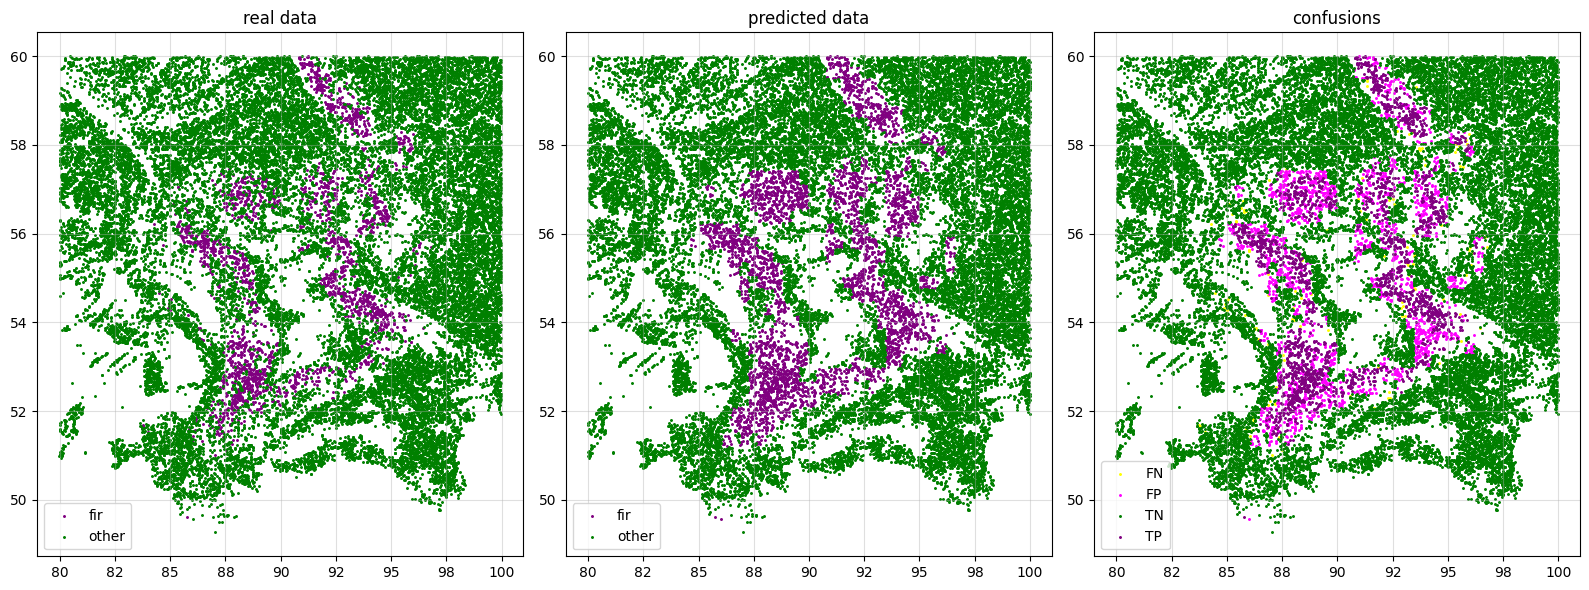

In [33]:
%matplotlib inline

from plot_map_and_save_data import plot_map_and_save_data

# Упорядочим столбцы в 'pred_test' так, 
# чтобы они встали в порядок, нужный для работы модели. 
pred_test = pred_test[model_best.feature_names_in_]

# Создадим и выведем на экран карту, если модель обучалась, 
# то сохраним её, исходные данные и результаты прогноза, 
# включая данные матрицы ошибок. 
plot_map_and_save_data(
    for_map=for_map, 
    predictors=predictors, 
    used_predictors=used_predictors,
    model=model_best, 
    pred_test=pred_test, 
    path_to_folder=path_to_trained_model
    )

## 4. Исследование лучшей модели

<div class='alert alert-info'>

Рассмотрим здесь, как значения предикторов влияют на результаты прогноза, и как предикторы связаны друг с другом. 

</div>

<div class='alert alert-info'>

Важно: уровни значимости, показанные на скрипичном графике ниже, рассчитаны по критерию Колмогорова – Смирнова.

</div>

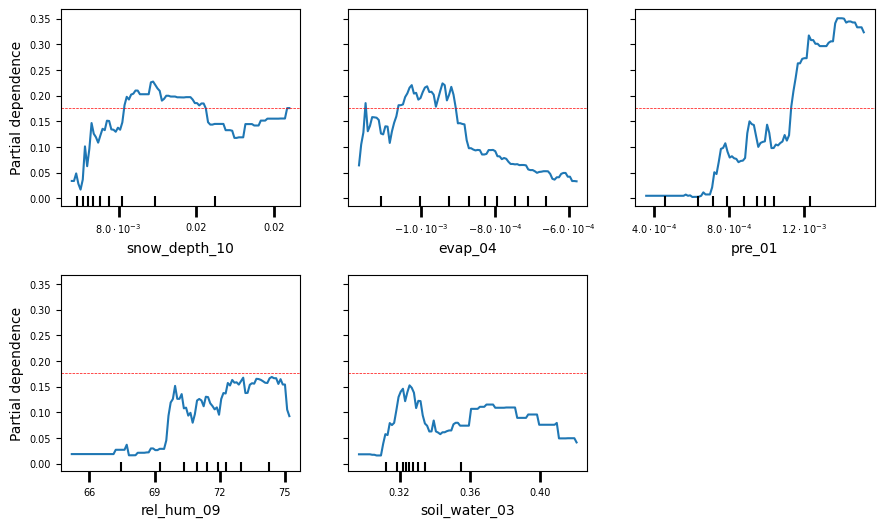

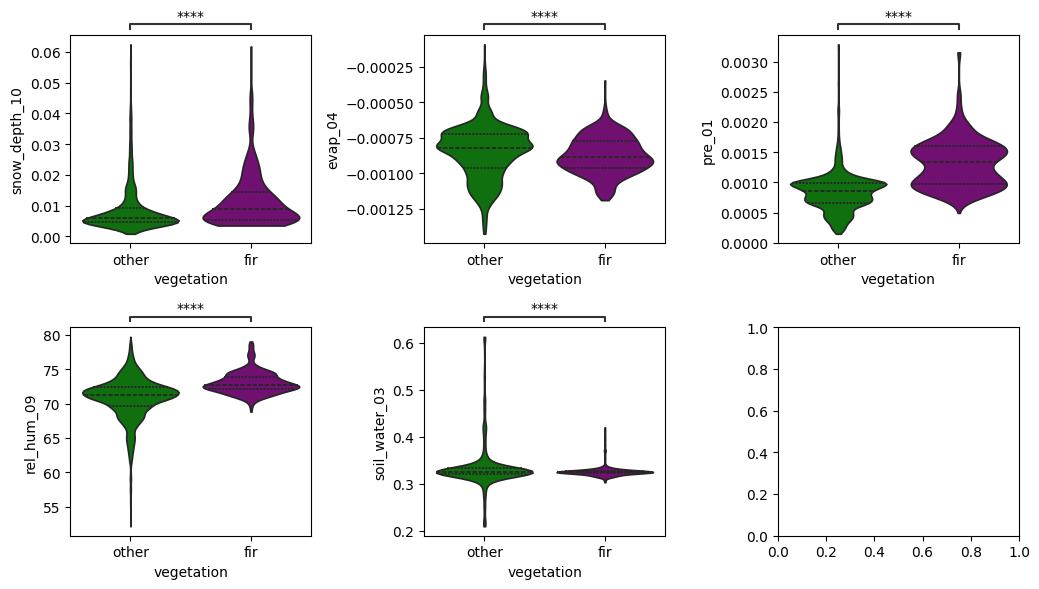

In [34]:
%matplotlib inline

# выведем на дисплй и сохраним в папки диаграммы частных зависимостей и скрипичные графики
from partial_deps_and_violins import partial_deps_and_violins

partial_deps_and_violins(
    model=model_best, 
    pred_test=pred_test, 
    veg_test=veg_test, 
    path_to_folder=path_to_trained_model
    )

## 5. Сравнение обученных моделей

<div class='alert alert-info'>

Здесь сравним метрики ранее обученых моделей и сопоставим их прогнозы. 

</div>

In [35]:
# загружаем данные из лога, если работаем с ранее обученной моделью
if COMPARE_MODELS_RESULTS: 
    from read_log import read_log

    # список моделей
    list_of_models = os.listdir(os.path.join(ROOT_DIR, 'models'))
    
    # список для сохранения целевых метрик исследуемых моделей
    target_metrics_of_models = []
    # счётчик
    k = 0

    for model in list_of_models: 
        target_metric, metrics, prognosis_data = read_log(
            root=ROOT_DIR, model_path=os.path.join(ROOT_DIR, 'models', model), mode='model'
            )
        target_metrics_of_models.append(target_metric)
        if k == 0:
            metrics_of_models = metrics
            results_of_prognosis = prognosis_data
            k += 1
        else: 
            metrics_of_models = pd.concat([metrics_of_models, metrics], ignore_index=True)
            results_of_prognosis = pd.concat([results_of_prognosis, prognosis_data], axis=1)

    metrics_of_models.index = target_metrics_of_models
    metrics_of_models = metrics_of_models.loc[
        metrics_of_models.iloc[:, 1:4].rank(ascending=False).sum(axis=1).sort_values().index, 
        ]
    results_of_prognosis.columns = target_metrics_of_models




In [36]:
if COMPARE_MODELS_RESULTS: 
    print('Метрики качества лучших моделей в зависимости от их целевых метрик: ')
    display(metrics_of_models)
    print('Алгоритмы отсортированы по сумме рангов их метрик от лучшего к худшему. ')
    if os.path.isdir(os.path.join(ROOT_DIR, MODELS_COMPARISON)):
        metrics_of_models.to_csv(os.path.join(ROOT_DIR, MODELS_COMPARISON, 'model_metrics.csv'))
    else: 
        os.mkdir(os.path.join(ROOT_DIR, MODELS_COMPARISON))
        metrics_of_models.to_csv(os.path.join(ROOT_DIR, MODELS_COMPARISON, 'model_metrics.csv'))
    

Метрики качества лучших моделей в зависимости от их целевых метрик: 


,algorythm,accuracy,precision,recall
fbeta_06,XGBoost,0.961979,0.808717,0.610603
fbeta_09,XGBoost,0.953516,0.638484,0.800731
fbeta_08,XGBoost,0.958073,0.804878,0.542962
fbeta_07,XGBoost,0.949349,0.618619,0.753199
roc_auc,XGBoost,0.936719,0.532551,0.912249


Алгоритмы отсортированы по сумме рангов их метрик от лучшего к худшему. 


<div class='alert alert-success'>

По всем метрикам, кроме *recall*, чуть-чуть лучше модель, обученная с целевой метрикой **Fbeta = 0.6**. Проверка по сумме рангов показала её преимущество. Её и будем использовать далее.

</div>

<div class='alert alert-info'>

Максимальное значение хи-квадрат при сравнении двух моделей и при двух возможных исходах равно количеству сравниваемых объектов (при выборке в 10_000 объектов это 20_000).

</div>

In [37]:
cross_tab = pd.crosstab(results_of_prognosis['fbeta_09'], results_of_prognosis['roc_auc'])

chi2_contingency(cross_tab)

Chi2ContingencyResult(statistic=np.float64(26424.751107191092), pvalue=np.float64(0.0), dof=1, expected_freq=array([[22980.08935547,  3326.91064453],
       [ 3854.91064453,   558.08935547]]))

In [38]:
if COMPARE_MODELS_RESULTS: 
    if os.path.isdir(os.path.join(ROOT_DIR, MODELS_COMPARISON)): 
        os.chdir(os.path.join(ROOT_DIR, MODELS_COMPARISON))
        try: 
            # попытаемся создать лог-файл и записать в него сопроводительную информацию
            with open('comparisons.txt', 'w') as file:
                file.write('Здесь сравниваем по критерию хи-квадрат результаты прогнозирования для всех обученных моделей. \n')
                file.write(f'Максимальное значение критерия хи-квадрат равно {2 * len(veg_train)}. \n\n')
        except: 
            print('Проблемы с записью в лог-файл')

    k = 1
    for target1 in target_metrics_of_models[:(len(target_metrics_of_models) - 1)]: 
        for target2 in target_metrics_of_models[k:]: 
            if target1 != target2:
                cross_tab = pd.crosstab(results_of_prognosis[target1], results_of_prognosis[target2])
                chi2, p_value, dof, expected  = chi2_contingency(cross_tab)
                print(f'Для целевых метрик {target1} и {target2} величина хи-квадрат равна {int(chi2)}, V Крамера {(int(chi2) / np.sum(expected)):.3F}, уровень значимости {p_value:.4e}.')
                print('-' * 20)

                if os.path.isdir(os.path.join(ROOT_DIR, MODELS_COMPARISON)): 
                    os.chdir(os.path.join(ROOT_DIR, MODELS_COMPARISON))
                    try: 
                        # попытаемся записать в лог-файл результаты сравнения по критерию хи-квадрат
                        with open('comparisons.txt', 'a') as file:     
                            file.write(f'Для целевых метрик {target1} и {target2} величина хи-квадрат равна {int(chi2)}, V Крамера {(int(chi2) / np.sum(expected)):.3F}, уровень значимости {p_value:.4e}. \n')
                    except: 
                        print('Проблемы с записью в лог-файл')
                else: 
                    os.mkdir(os.path.join(ROOT_DIR, MODELS_COMPARISON))
                    os.chdir(os.path.join(ROOT_DIR, MODELS_COMPARISON))
                    try: 
                        # попытаемся создать лог-файл и записать в него дату работы
                        with open('comparisons.txt', 'a') as file:     
                            file.write(f'Для целевых метрик {target1} и {target2} величина хи-квадрат равна {int(chi2)}, V Крамера {(int(chi2) / np.sum(expected)):.3F}, уровень значимости {p_value:.4e}. \n')
                    except: 
                        print('Проблемы с записью в лог-файл')                    
        k += 1


Для целевых метрик fbeta_06 и fbeta_07 величина хи-квадрат равна 16862, V Крамера 0.549, уровень значимости 0.0000e+00.
--------------------
Для целевых метрик fbeta_06 и fbeta_08 величина хи-квадрат равна 25178, V Крамера 0.820, уровень значимости 0.0000e+00.
--------------------
Для целевых метрик fbeta_06 и fbeta_09 величина хи-квадрат равна 10961, V Крамера 0.357, уровень значимости 0.0000e+00.
--------------------
Для целевых метрик fbeta_06 и roc_auc величина хи-квадрат равна 12700, V Крамера 0.413, уровень значимости 0.0000e+00.
--------------------
Для целевых метрик fbeta_07 и fbeta_08 величина хи-квадрат равна 15675, V Крамера 0.510, уровень значимости 0.0000e+00.
--------------------
Для целевых метрик fbeta_07 и fbeta_09 величина хи-квадрат равна 17369, V Крамера 0.565, уровень значимости 0.0000e+00.
--------------------
Для целевых метрик fbeta_07 и roc_auc величина хи-квадрат равна 18476, V Крамера 0.601, уровень значимости 0.0000e+00.
--------------------
Для целевых мет